# Shared Feature Matrix and Time-Based Data Splits

This notebook explains how the approved forecasting inputs become one shared matrix and how the historical data is divided for training, validation, and final testing.

The same inputs and date boundaries will be used by every later forecasting model.

## 1. Why this preparation matters

The target demand is kept separate from the predictors. The rows are split by date rather than randomly, because a forecasting model must be tested on later months than the months used for learning.

The first 12 source months are removed because the feature set needs a complete 12-month demand history. No missing values are filled with future information.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.phase4_data_loader import load_dnh_total_dataset
from src.features.phase4_dataset_preparation import (
    create_chronological_splits,
    describe_chronological_splits,
    prepare_shared_feature_matrix,
    save_prepared_artifacts,
)

FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'matrix_splits'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Build the shared matrix

In [2]:
data = load_dnh_total_dataset()
features, target = prepare_shared_feature_matrix(data)
splits = create_chronological_splits(features, target)
split_summary = describe_chronological_splits(splits)

overview = pd.Series({
    'source rows': len(data),
    'complete feature rows': len(features),
    'approved predictors': len(features.columns),
    'feature period': f"{features.index.min():%Y-%m} to {features.index.max():%Y-%m}",
    'target': target.name,
    'warm-up rows removed': len(data) - len(features),
})
display(overview.to_frame('value'))
assert features.shape == (168, 28)
assert target.name == 'residential_water_demand_m3'
assert target.name not in features.columns
assert features.notna().all().all()

,value
source rows,180
complete feature rows,168
approved predictors,28
feature period,2011-01 to 2024-12
target,residential_water_demand_m3
warm-up rows removed,12


## 3. Chronological partitions

The complete matrix uses 108 training months, 24 validation months, and the final 36 months as an untouched test period. The training count is adjusted because the first 12 source rows were removed for feature warm-up.

,split,rows,start_date,end_date,feature_count
0,train,108,2011-01-01,2019-12-01,28
1,validation,24,2020-01-01,2021-12-01,28
2,test,36,2022-01-01,2024-12-01,28


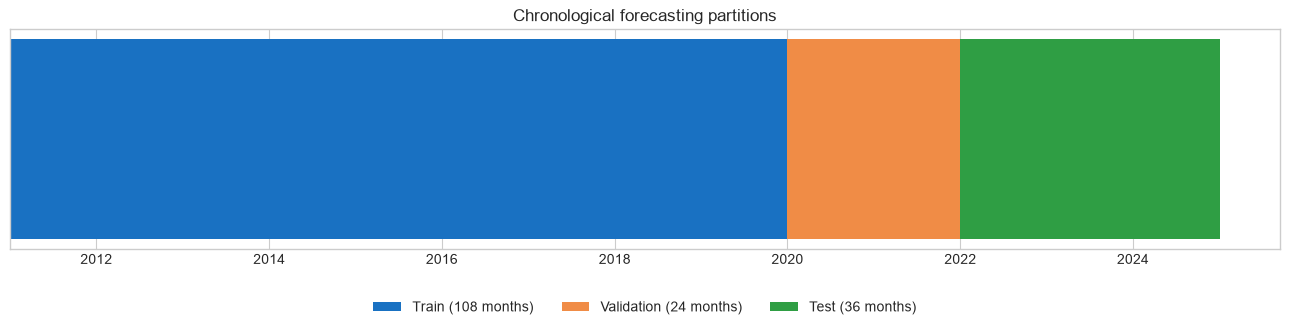

In [3]:
display(split_summary)
assert split_summary['rows'].tolist() == [108, 24, 36]
assert split_summary['start_date'].tolist() == ['2011-01-01', '2020-01-01', '2022-01-01']
assert split_summary['end_date'].tolist() == ['2019-12-01', '2021-12-01', '2024-12-01']

colors = {'train': '#1971c2', 'validation': '#f08c46', 'test': '#2f9e44'}
fig, ax = plt.subplots(figsize=(13, 3.5))
for _, row in split_summary.iterrows():
    start = pd.Timestamp(row['start_date'])
    end = pd.Timestamp(row['end_date']) + pd.offsets.MonthBegin(1)
    ax.barh(0, (end - start).days, left=start, height=0.45, color=colors[row['split']], label=f"{row['split'].title()} ({row['rows']} months)")
ax.set_title('Chronological forecasting partitions')
ax.set_yticks([])
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_chronological_split_timeline.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Save the shared artifacts

The feature matrix, separate target, split views, and date-boundary metadata are saved so later models cannot accidentally reconstruct different partitions.

In [4]:
artifact_paths = save_prepared_artifacts(features, target, splits)
for name, path in artifact_paths.items():
    print(f'{name}: {path}')
assert artifact_paths['features'].exists()
assert artifact_paths['target'].exists()
assert artifact_paths['metadata'].exists()
print('Prepared rows:', len(features), 'Predictors:', len(features.columns), 'Test rows:', len(splits['test'][0]))

features: data\processed\features\dnh_total_monthly_features_v1.csv
target: data\processed\features\dnh_total_monthly_target_v1.csv
metadata: data\processed\splits\dnh_total_split_metadata_v1.json
train_features: data\processed\splits\train_features_v1.csv
train_target: data\processed\splits\train_target_v1.csv
train_row_ids: data\processed\splits\train_row_ids_v1.json
validation_features: data\processed\splits\validation_features_v1.csv
validation_target: data\processed\splits\validation_target_v1.csv
validation_row_ids: data\processed\splits\validation_row_ids_v1.json
test_features: data\processed\splits\test_features_v1.csv
test_target: data\processed\splits\test_target_v1.csv
test_row_ids: data\processed\splits\test_row_ids_v1.json
Prepared rows: 168 Predictors: 28 Test rows: 36


## 5. Plain-language conclusion

Every later model will receive the same 28 predictors, the same separate target, and the same chronological train/validation/test periods. The final 36 months remain untouched until final evaluation.